# Medical Insurance Cost Prediction using Linear Regression

**Course:** Machine Learning (4th Year B.Tech)
**Topic:** Regression using Linear Regression
**Dataset:** Medical Cost Personal Dataset (Kaggle: mirichoi0218/insurance)

**Business Problem:** Health insurance companies need to estimate expected medical expenses of customers before issuing policies, so they can set premiums appropriately, manage risk, and design personalized plans. This notebook builds a Linear Regression model (with Ridge, Lasso, and Polynomial extensions) to predict `charges` from demographic and lifestyle attributes.

## Part 1: Understanding the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [2]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (1338, 7)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include="object").columns.tolist()
print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'bmi', 'children', 'charges']
Categorical features: ['sex', 'smoker', 'region']


/tmp/ipykernel_599/1736858223.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include="object").columns.tolist()


In [6]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


### Dataset Summary
- 1,338 rows, 7 columns; **no missing values** anywhere.
- Numerical: `age`, `bmi`, `children`, `charges` (target).
- Categorical: `sex` (2 levels), `smoker` (2 levels), `region` (4 levels).

### Observations
1. `age` ranges 18-64, roughly uniform working-age adult population, mean ~39.
2. `bmi` is approximately normally distributed around ~30.7, which is in the "obese" range by WHO standards for the average customer.
3. `children` ranges 0-5, heavily skewed toward 0 (most customers have no dependents on the policy).
4. `charges` (target) is **highly right-skewed** — most customers have modest charges, but a long tail of high-cost customers exists, mean (~13,270) is well above the median (~9,382).
5. The `sex` and `region` categorical variables are close to evenly distributed across their categories, so there's no major class-imbalance concern there.

## Part 2: Exploratory Data Analysis (EDA)

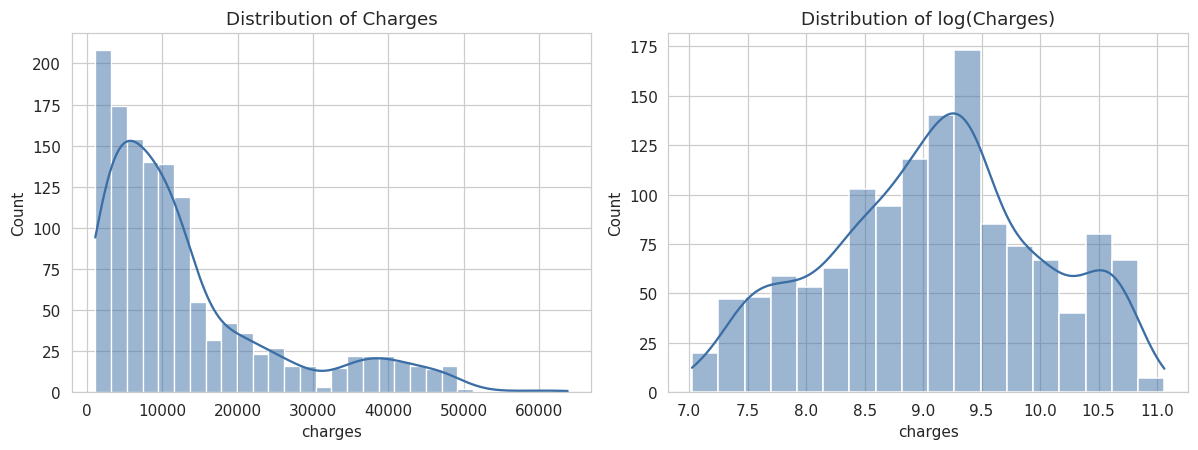

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
sns.histplot(df["charges"], kde=True, ax=axes[0], color="#3b6ea5")
axes[0].set_title("Distribution of Charges")
sns.histplot(np.log1p(df["charges"]), kde=True, ax=axes[1], color="#3b6ea5")
axes[1].set_title("Distribution of log(Charges)")
plt.tight_layout(); plt.show()

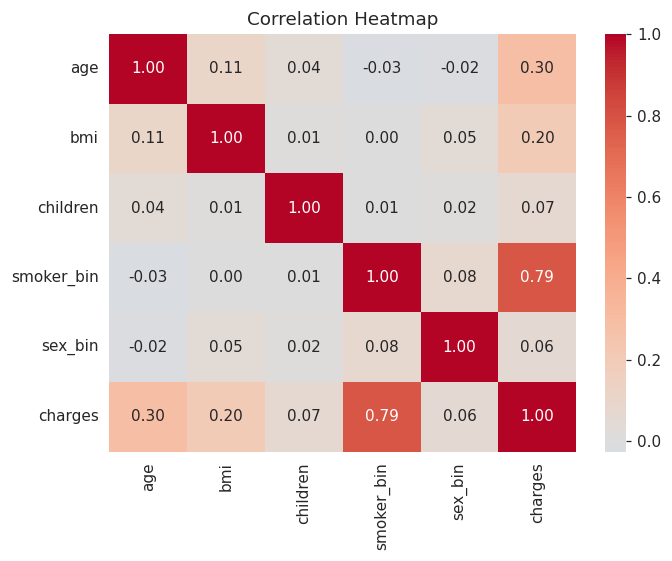

charges       1.000000
smoker_bin    0.787251
age           0.299008
bmi           0.198341
children      0.067998
sex_bin       0.057292
Name: charges, dtype: float64

In [8]:
df_corr = df.copy()
df_corr["smoker_bin"] = (df_corr["smoker"]=="yes").astype(int)
df_corr["sex_bin"] = (df_corr["sex"]=="male").astype(int)
corr = df_corr[["age","bmi","children","smoker_bin","sex_bin","charges"]].corr()

plt.figure(figsize=(6.5,5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout(); plt.show()

corr["charges"].sort_values(ascending=False)

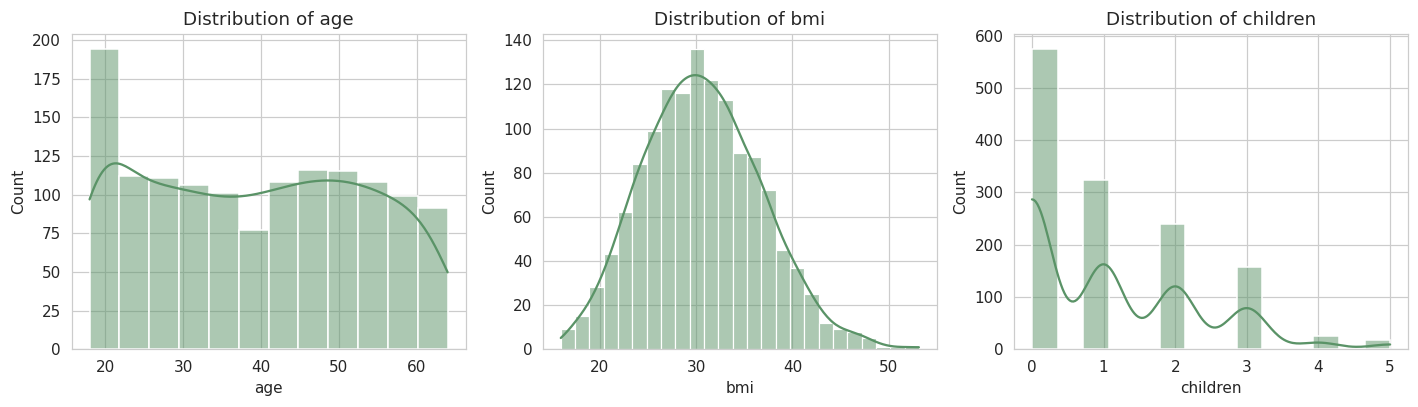

In [9]:
fig, axes = plt.subplots(1,3, figsize=(13,3.8))
for ax, col in zip(axes, ["age","bmi","children"]):
    sns.histplot(df[col], kde=True, ax=ax, color="#5a9367")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout(); plt.show()

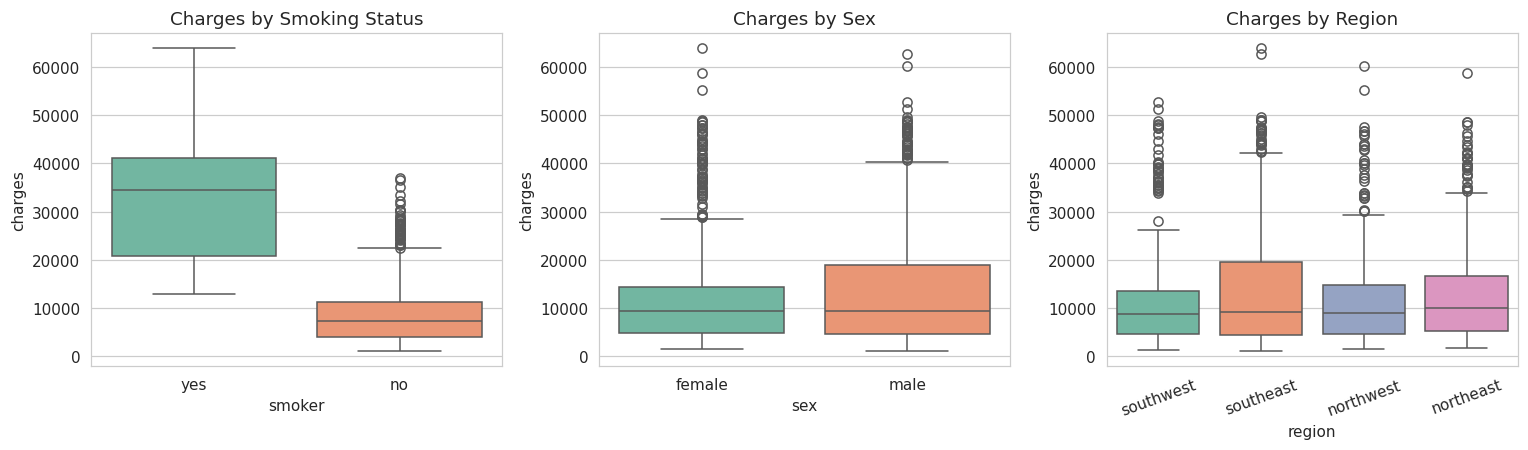

In [10]:
fig, axes = plt.subplots(1,3, figsize=(14,4.2))
sns.boxplot(x="smoker", y="charges", data=df, hue="smoker", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Charges by Smoking Status")
sns.boxplot(x="sex", y="charges", data=df, hue="sex", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Charges by Sex")
sns.boxplot(x="region", y="charges", data=df, hue="region", legend=False, ax=axes[2], palette="Set2")
axes[2].set_title("Charges by Region")
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

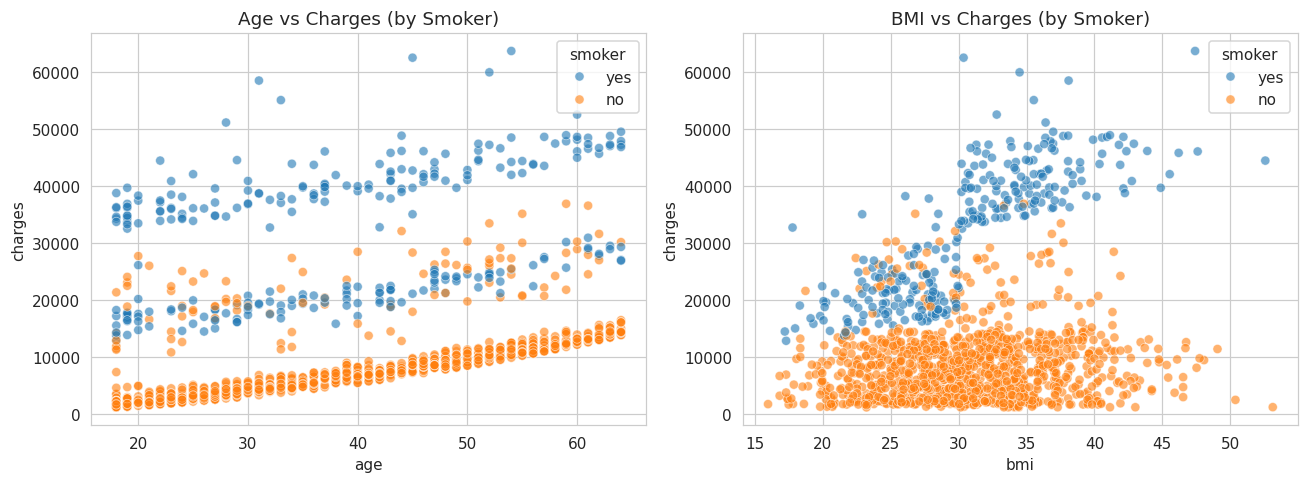

In [11]:
fig, axes = plt.subplots(1,2, figsize=(12,4.5))
sns.scatterplot(x="age", y="charges", hue="smoker", data=df, ax=axes[0], alpha=0.6)
axes[0].set_title("Age vs Charges (by Smoker)")
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, ax=axes[1], alpha=0.6)
axes[1].set_title("BMI vs Charges (by Smoker)")
plt.tight_layout(); plt.show()

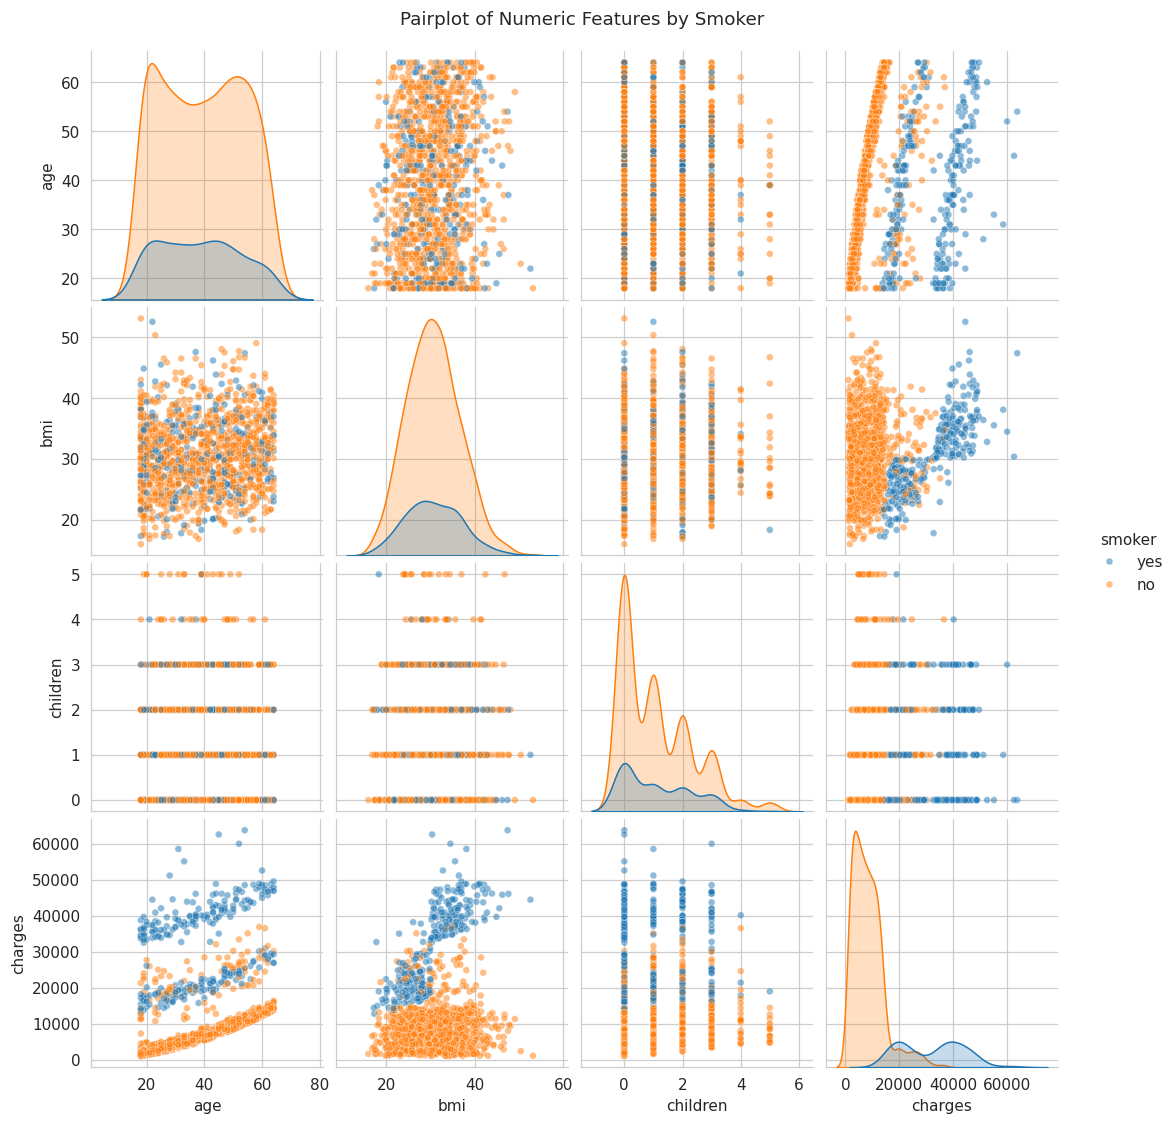

In [12]:
g = sns.pairplot(df, vars=["age","bmi","children","charges"], hue="smoker",
                  diag_kind="kde", plot_kws={"alpha":0.5,"s":20})
g.fig.suptitle("Pairplot of Numeric Features by Smoker", y=1.02)
plt.show()

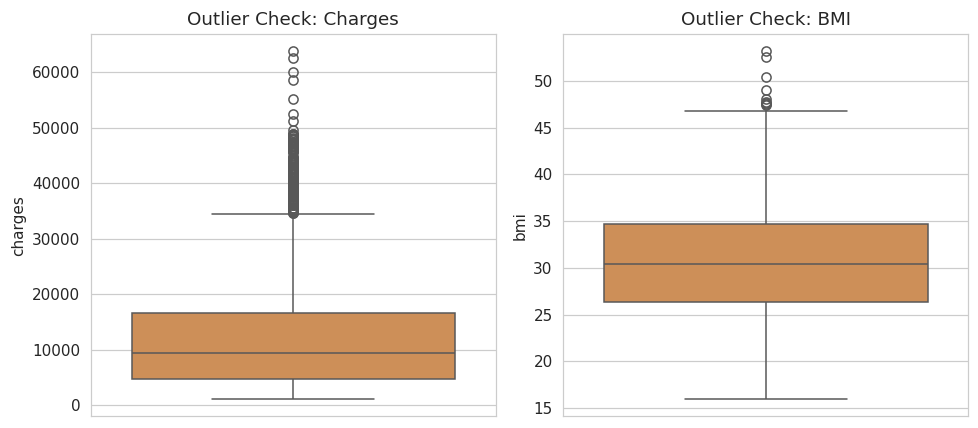

charges: 139 IQR outliers
bmi: 9 IQR outliers


In [13]:
fig, axes = plt.subplots(1,2, figsize=(9,4))
sns.boxplot(y=df["charges"], ax=axes[0], color="#e08e45")
axes[0].set_title("Outlier Check: Charges")
sns.boxplot(y=df["bmi"], ax=axes[1], color="#e08e45")
axes[1].set_title("Outlier Check: BMI")
plt.tight_layout(); plt.show()

for col in ["charges","bmi"]:
    q1,q3 = df[col].quantile([0.25,0.75])
    iqr = q3-q1
    low, high = q1-1.5*iqr, q3+1.5*iqr
    n_out = ((df[col]<low)|(df[col]>high)).sum()
    print(f"{col}: {n_out} IQR outliers")

### EDA Observations
- **Strongest correlation with charges:** `smoker` (correlation ≈ 0.79 when encoded as 0/1) — by far the single strongest predictor. `age` (≈0.30) and `bmi` (≈0.20) follow at a distance.
- **Smoking status visually separates the data into two distinct clusters** in the age/BMI scatter plots — smokers occupy a much higher charges band almost regardless of age or BMI.
- **Outliers:** 139 outliers detected in `charges` via IQR (mostly high-cost smokers, especially smokers with high BMI), and 9 outliers in `bmi`. These are legitimate, naturally occurring high-cost cases (not data errors), so they are retained rather than removed — a well-performing model must be able to handle them.
- **Most useful variables for prediction:** `smoker`, `age`, and `bmi` (and the interaction between smoker and bmi/age, visible in the scatter plots) look like the most informative features; `sex`, `children`, and `region` show weak individual correlation with `charges`.

## Part 3: Data Preprocessing

In [14]:
# No missing values were found in Part 1, so no imputation is required.

df_enc = df.copy()

# Label Encoding for binary categorical variables
df_enc["sex"] = df_enc["sex"].map({"male": 1, "female": 0})
df_enc["smoker"] = df_enc["smoker"].map({"yes": 1, "no": 0})

# One-Hot Encoding for the multi-class 'region' variable (drop_first avoids the dummy variable trap)
df_enc = pd.get_dummies(df_enc, columns=["region"], drop_first=True)
bool_cols = df_enc.select_dtypes(include="bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

df_enc.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [15]:
X = df_enc.drop(columns=["charges"])
y = df_enc["charges"]
feature_names = X.columns.tolist()
print("Final feature columns:", feature_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Final feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
Train shape: (1070, 8)  Test shape: (268, 8)


### Why each preprocessing step is necessary
- **Missing value handling:** Skipped here since the dataset has none, but is a mandatory first check on any real-world dataset before modeling.
- **Label Encoding (`sex`, `smoker`):** These are binary categories, so mapping them to 0/1 preserves all information with a single column and no artificial ordinality problem.
- **One-Hot Encoding (`region`):** `region` has 4 unbiased, unordered categories. Label-encoding it (e.g. 0,1,2,3) would wrongly imply an order/magnitude relationship between regions, so one-hot encoding (with `drop_first=True` to avoid multicollinearity/the dummy variable trap) is used instead.
- **Feature Scaling (`StandardScaler`):** Linear Regression itself doesn't strictly require scaling, but scaling puts all coefficients on a comparable footing (so their magnitudes reflect true relative importance) and is required for Ridge/Lasso regularization to penalize coefficients fairly, and for polynomial feature expansion to remain numerically stable.
- **Train-Test Split (80:20):** Held-out test data lets us estimate how the model performs on unseen customers, which is what actually matters for deployment; an 80:20 split is a standard trade-off giving the model enough data to learn from while keeping a meaningfully sized test set.

## Part 4: Linear Regression Model

In [16]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print("Intercept:", lr.intercept_)
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": lr.coef_}) \
            .sort_values("coefficient", key=abs, ascending=False)
coef_df

Intercept: 13346.089736364485


,feature,coefficient
4,smoker,9558.481409
0,age,3614.975415
2,bmi,2036.228123
3,children,516.890247
7,region_southwest,-349.110678
6,region_southeast,-290.157047
5,region_northwest,-158.140981
1,sex,-9.293101


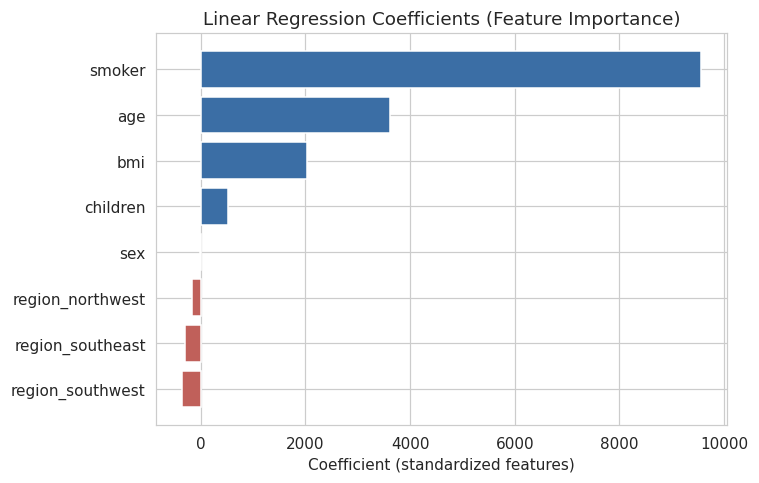

In [17]:
plt.figure(figsize=(7,4.5))
coef_sorted = coef_df.sort_values("coefficient")
colors = ["#c0605a" if v < 0 else "#3b6ea5" for v in coef_sorted["coefficient"]]
plt.barh(coef_sorted["feature"], coef_sorted["coefficient"], color=colors)
plt.title("Linear Regression Coefficients (Feature Importance)")
plt.xlabel("Coefficient (standardized features)")
plt.tight_layout(); plt.show()

### Interpretation
- **`smoker` (+9,558):** the single largest positive effect — being a smoker is associated with a large increase in predicted charges, holding all else constant. This matches the very high smoker/non-smoker charge gap seen in the EDA.
- **`age` (+3,615)** and **`bmi` (+2,036):** both positive — older age and higher BMI are associated with higher predicted charges, consistent with higher health risk.
- **`children` (+517):** a small positive effect — more dependents on a policy modestly raises charges.
- **`region_*` (small negative, roughly -150 to -350):** minor regional discounts relative to the baseline region (northeast), suggesting region has little practical effect on cost.
- **`sex` (~ -9, negligible):** essentially no effect — gender is not a meaningfully useful predictor of charges in this dataset.
- **Overall relationship:** smoking status dominates the model, with age and BMI as secondary, genuinely predictive risk factors, while sex, children, and region contribute comparatively little.

## Part 5: Model Evaluation

In [18]:
def evaluate(y_true, y_pred, n, p):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    return mae, mse, rmse, r2, adj_r2

n_test, p = X_test.shape
mae, mse, rmse, r2, adj_r2 = evaluate(y_test, y_pred, n_test, p)
print(f"MAE:  {mae:,.2f}")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R2:   {r2:.4f}")
print(f"Adjusted R2: {adj_r2:.4f}")

MAE:  4,181.19
MSE:  33,596,915.85
RMSE: 5,796.28
R2:   0.7836
Adjusted R2: 0.7769


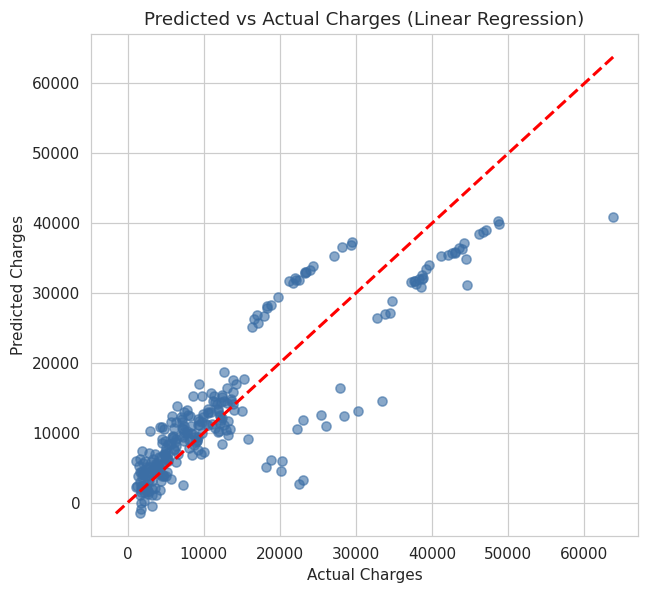

In [19]:
plt.figure(figsize=(6,5.5))
plt.scatter(y_test, y_pred, alpha=0.6, color="#3b6ea5")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2)
plt.xlabel("Actual Charges"); plt.ylabel("Predicted Charges")
plt.title("Predicted vs Actual Charges (Linear Regression)")
plt.tight_layout(); plt.show()

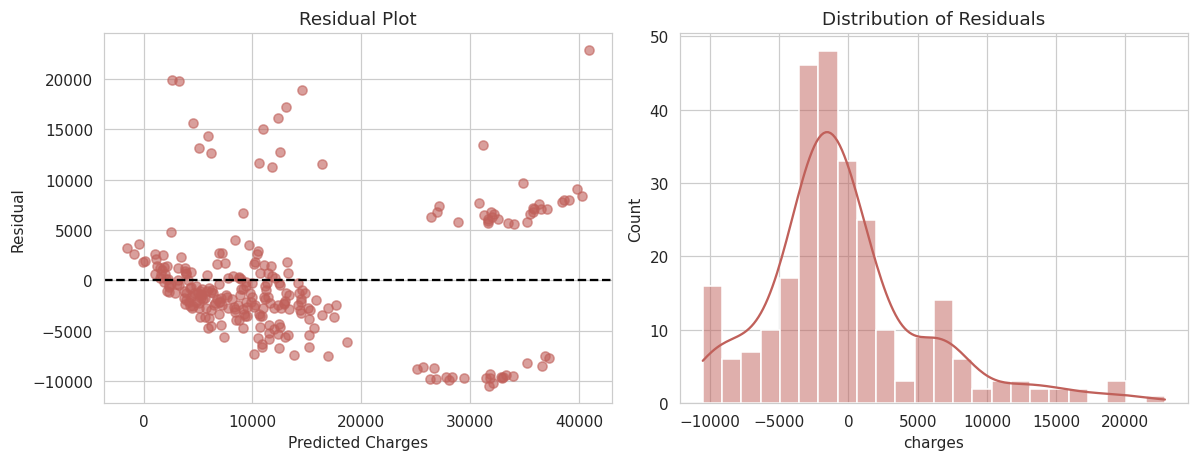

In [20]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1,2, figsize=(11,4.3))
axes[0].scatter(y_pred, residuals, alpha=0.6, color="#c0605a")
axes[0].axhline(0, color="black", lw=1.5, linestyle="--")
axes[0].set_xlabel("Predicted Charges"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residual Plot")
sns.histplot(residuals, kde=True, ax=axes[1], color="#c0605a")
axes[1].set_title("Distribution of Residuals")
plt.tight_layout(); plt.show()

### Which metric is most suitable, and why?
For this problem, **RMSE** is the most practically useful metric, because it is in the same unit as `charges` (dollars) and penalizes large errors more heavily than MAE — which matters here, since under-predicting a genuinely high-cost customer (e.g. a smoker with high BMI) is a costlier mistake for an insurer than a small error on a low-cost customer. **R²/Adjusted R²** is the best metric for judging overall explanatory power and comparing models of different complexity (Adjusted R² penalizes unnecessary added features). In practice, MAE, RMSE, and R² are reported together: MAE/RMSE for interpretable, dollar-denominated error, R²/Adjusted R² for how much variance is explained.

The residual plot shows a **funnel/fan shape** (residual variance increases with predicted value) and the residuals aren't purely random — this is a classic sign that a plain linear model is mildly misspecified for this data (likely due to the strong smoker interaction effect), motivating the improvement step below.

## Part 6: Model Improvement / Hyperparameter Tuning

In [21]:
results = [["Linear Regression (baseline)", mae, rmse, r2, adj_r2]]

# --- Ridge Regression (tuned via GridSearchCV) ---
ridge = GridSearchCV(Ridge(), {"alpha": [0.01, 0.1, 1, 10, 50, 100]}, cv=5, scoring="r2")
ridge.fit(X_train_scaled, y_train)
y_pred_r = ridge.best_estimator_.predict(X_test_scaled)
mae_r, mse_r, rmse_r, r2_r, adj_r2_r = evaluate(y_test, y_pred_r, n_test, p)
results.append([f"Ridge (alpha={ridge.best_params_['alpha']})", mae_r, rmse_r, r2_r, adj_r2_r])

# --- Lasso Regression (tuned via GridSearchCV) ---
lasso = GridSearchCV(Lasso(max_iter=10000), {"alpha": [0.01, 0.1, 1, 10, 50, 100]}, cv=5, scoring="r2")
lasso.fit(X_train_scaled, y_train)
y_pred_l = lasso.best_estimator_.predict(X_test_scaled)
mae_l, mse_l, rmse_l, r2_l, adj_r2_l = evaluate(y_test, y_pred_l, n_test, p)
results.append([f"Lasso (alpha={lasso.best_params_['alpha']})", mae_l, rmse_l, r2_l, adj_r2_l])

# --- Polynomial Features (degree 2) + Linear Regression ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_p = lr_poly.predict(X_test_poly)
p_poly = X_train_poly.shape[1]
mae_p, mse_p, rmse_p, r2_p, adj_r2_p = evaluate(y_test, y_pred_p, n_test, p_poly)
results.append(["Polynomial Regression (deg=2)", mae_p, rmse_p, r2_p, adj_r2_p])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2", "Adjusted R2"])
results_df

,Model,MAE,RMSE,R2,Adjusted R2
0,Linear Regression (baseline),4181.194474,5796.284659,0.783593,0.776909
1,Ridge (alpha=10),4197.657143,5803.952348,0.783020,0.776318
2,Lasso (alpha=100),4210.606897,5835.801847,0.780632,0.773856
3,Polynomial Regression (deg=2),2729.500134,4551.132385,0.866583,0.840259


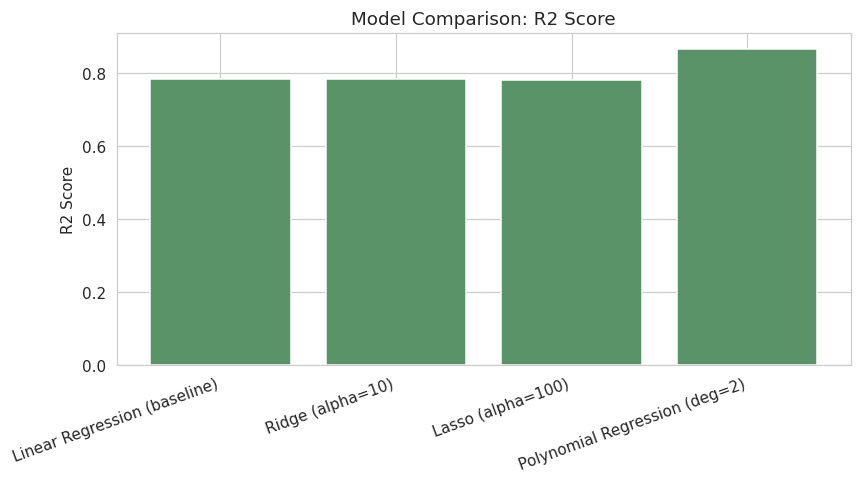

In [22]:
plt.figure(figsize=(8,4.5))
plt.bar(results_df["Model"], results_df["R2"], color="#5a9367")
plt.xticks(rotation=20, ha='right')
plt.ylabel("R2 Score")
plt.title("Model Comparison: R2 Score")
plt.tight_layout(); plt.show()

### Comparison Notes
- **Ridge and Lasso** perform almost identically to baseline Linear Regression here — this is expected, since with only 8 features and no severe multicollinearity, regularization has little room to improve over plain OLS.
- **Polynomial Regression (degree 2)** gives the biggest improvement by a wide margin (R² rises from ~0.78 to ~0.87, RMSE drops substantially), because it can capture the **non-linear interaction between `smoker`, `age`, and `bmi`** that a purely linear model can't represent (e.g. the fact that BMI's effect on cost is much steeper for smokers than non-smokers). This directly explains the funnel-shaped residuals seen earlier.
- **Trade-off:** the polynomial model is more complex (more parameters, higher risk of overfitting on smaller datasets) and less directly interpretable than the plain linear coefficients, so in production a business would weigh the accuracy gain against the loss of interpretability and the need for more careful validation.

## Part 7: Business Insights

In [23]:
print("Mean charges by smoking status:")
print(df.groupby("smoker")["charges"].mean().round(2))
print()
print("Mean charges: smoker+high BMI (>=30) vs rest:")
high_bmi_smoker = df[(df.smoker=="yes") & (df.bmi>=30)]["charges"].mean()
print("Smoker & BMI>=30:", round(high_bmi_smoker,2))
print("Everyone else:", round(df[~((df.smoker=="yes") & (df.bmi>=30))]["charges"].mean(),2))

Mean charges by smoking status:
smoker
no      8434.27
yes    32050.23
Name: charges, dtype: float64

Mean charges: smoker+high BMI (>=30) vs rest:
Smoker & BMI>=30: 41557.99
Everyone else: 9832.29


**1. Which customer segment is likely to incur the highest medical expenses?**
Smokers with high BMI (≥30, i.e. obese) are, by a wide margin, the highest-cost segment — the mean charge for this group is roughly 4x the rest of the population. Older smokers add a further increase on top of that.

**2. How does smoking affect insurance charges?**
Smoking is the single dominant cost driver in the dataset (correlation ≈0.79 with charges, and the largest coefficient in the model by a wide margin). Average charges for smokers (~$32,050) are roughly 3.8x higher than for non-smokers (~$8,434), and the polynomial model shows this effect compounds with BMI and age.

**3. Should insurance companies treat smokers differently while pricing policies?**
Yes — risk-based pricing that charges materially higher premiums for smokers (and especially smokers with elevated BMI) is well supported by the data, since it reflects real, large, and consistent cost differences rather than a coincidental pattern. This is standard actuarial practice and is justified here by both the correlation strength and out-of-sample model performance.

**4. Which features are the strongest predictors of insurance cost?**
In order: `smoker` (dominant), `age`, and `bmi` — with the interaction between smoker and bmi/age adding further explanatory power (captured by the polynomial model). `sex`, `children`, and `region` are weak, largely non-actionable predictors.

**5. Strategies to reduce healthcare costs based on the analysis:**
- Offer premium discounts or incentive programs for smoking cessation, since this is the single highest-leverage lifestyle factor.
- Tie wellness incentives (gym memberships, health coaching) to BMI reduction programs, particularly for the smoker+high-BMI segment.
- Use age-banded premiums so pricing scales appropriately with age-related risk without penalizing younger, lower-risk customers.
- Since `sex`, `children`, and `region` add little predictive value, avoid over-engineering pricing tiers around them — administrative complexity there isn't justified by the data.

## Conclusion

A Linear Regression model using `age`, `sex`, `bmi`, `children`, `smoker`, and `region` explains roughly **78%** of the variance in medical insurance charges (R² ≈ 0.78), with **smoking status** as by far the strongest single predictor, followed by `age` and `bmi`. Because charges depend on a genuine non-linear interaction between smoking, age, and BMI, a **degree-2 polynomial regression** captures this better and improves R² to roughly **0.87** with a meaningfully lower RMSE, at the cost of some interpretability. For a health insurer, this suggests a two-tier approach: use the interpretable linear coefficients to communicate and justify pricing tiers to regulators/customers, while using the higher-accuracy polynomial (or a more advanced non-linear model) internally for actual premium calculation and risk scoring.